<a href="https://colab.research.google.com/github/msmk85/Assignment-3/blob/main/Calorie_Burn_Prediction_%26_Workout_Pattern_Clustering_Using_Fitbit_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ---------------------------------------------------------
# DATASET
# ---------------------------------------------------------

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np



from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


# ---------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------
data = pd.read_csv("/content/Fitbit_dataset.csv")
data.rename(columns={'Calories_Burned (kcal)': 'Calories'}, inplace=True)

print("Dataset Shape:", data.shape)
print("Columns:", data.columns)

# ---------------------------------------------------------
# 3. HANDLE MISSING VALUES
# ---------------------------------------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

# Fill numeric missing values with mean
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Fill categorical missing values with mode
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# ---------------------------------------------------------
# 4. OUTLIER REMOVAL (IQR METHOD)
# ---------------------------------------------------------
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = np.where(data[col] < lower, lower,
                 np.where(data[col] > upper, upper, data[col]))

# ---------------------------------------------------------
# 5. ENCODE CATEGORICAL COLUMNS
# ---------------------------------------------------------
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# ---------------------------------------------------------
# 6. FEATURE SCALING
# ---------------------------------------------------------
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# ---------------------------------------------
# RANDOM FOREST REGRESSION
# ---------------------------------------------

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Split data
X = data.drop('Calories', axis=1)
y = data['Calories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Create Random Forest Model (Tuned Parameters)
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=40,        # increased from 20 → slightly stronger
    max_depth=4,            # increased from 3 → learns a bit more
    min_samples_split=20,   # same (controls overfitting)
    min_samples_leaf=10,    # same (smooth predictions)
    max_features=0.3,       # same (limits learning)
    random_state=42,
    n_jobs=-1
)

# 3. Train the model
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# 5. Evaluate
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

Dataset Shape: (14102, 19)
Columns: Index(['Unnamed: 0', 'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM',
       'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
       'HR_Intensity', 'Effective_MET', 'Calories'],
      dtype='object')
R² Score: 0.8540638023264802


In [ ]:
# ---------------------------------------------
# Linear Regression
# ---------------------------------------------

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = data.drop('Calories', axis=1)
y = data['Calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("Linear Regression R²:", r2_score(y_test, y_pred))


Linear Regression R²: 0.9262265687275208


In [ ]:
# ---------------------------------------------
# Ridge Regression
# ---------------------------------------------

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Split data
X = data.drop('Calories', axis=1)
y = data['Calories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ridge Regression with controlled alpha
ridge = Ridge(alpha=5)   # try 3, 5, 7 for fine tuning
ridge.fit(X_train, y_train)

# Predict
y_pred = ridge.predict(X_test)

# Evaluate
print("Ridge Regression R²:", r2_score(y_test, y_pred))


Ridge Regression R²: 0.9261911751666443


In [ ]:
# ---------------------------------------------
# Lasso Regression
# ---------------------------------------------

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Split data
X = data.drop('Calories', axis=1)
y = data['Calories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Lasso Regression with controlled alpha
lasso = Lasso(alpha=0.01)   # try 0.005, 0.01, 0.02 for fine tuning
lasso.fit(X_train, y_train)

# Predict
y_pred = lasso.predict(X_test)

# Evaluate
print("Lasso Regression R²:", r2_score(y_test, y_pred))


Lasso Regression R²: 0.9235205554455133


In [ ]:
# ---------------------------------------------
# KNN Regression
# ---------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# Split data
X = data.drop('Calories', axis=1)
y = data['Calories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn = KNeighborsRegressor(
    n_neighbors=8,      # best range for your target R²
    weights='distance', # improves accuracy
    metric='minkowski', # default distance
    p=2                 # Euclidean distance
)

knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Evaluate
print("KNN Regression R²:", r2_score(y_test, y_pred))


KNN Regression R²: 0.9404567589606708


In [ ]:
# ---------------------------------------------
# XGBoost
# ---------------------------------------------

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Split data
X = data.drop('Calories', axis=1)
y = data['Calories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost
model = XGBRegressor(
    n_estimators=200,       # moderate number of trees
    learning_rate=0.08,     # slightly slow learning
    max_depth=4,            # shallow trees → prevents overfitting
    subsample=0.8,          # use 80% of rows
    colsample_bytree=0.7,   # use 70% of features
    gamma=0.2,              # regularization
    reg_lambda=1.0,         # L2 regularization
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("XGBoost R²:", r2_score(y_test, y_pred))


XGBoost R²: 0.9945244107156708


In [ ]:
# ---------------------------------------------
# Decision Tree
# ---------------------------------------------


from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Split data
X = data.drop('Calories', axis=1)
y = data['Calories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree (controlled complexity)
model = DecisionTreeRegressor(
    max_depth=6,           # controls tree growth
    min_samples_split=20,  # prevents overfitting
    min_samples_leaf=10,   # smoother predictions
    max_features=0.7,      # use 70% of features
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Decision Tree R²:", r2_score(y_test, y_pred))


Decision Tree R²: 0.9279425324860752


In [ ]:
# ---------------------------------------------
# Support Vector Regression (SVR)
# ---------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score

# Split data
X = data.drop('Calories', axis=1)
y = data['Calories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVR(
    kernel='rbf',      # best for nonlinear fitness data
    C=5,               # controls model strength
    epsilon=0.1,       # margin of tolerance
    gamma=0.05         # controls curve smoothness
)

model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
print("SVR R²:", r2_score(y_test, y_pred))



SVR R²: 0.9953240386727887


In [ ]:
# ---------------------------------------------
# ALL MODELS
# ---------------------------------------------


import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import numpy as np

# -----------------------------
# 1. Train-Test Split
# -----------------------------
X = data.drop('Calories', axis=1)
y = data['Calories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2. Scaling (needed for KNN & SVR)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 3. Define Models
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=5),
    "Lasso Regression": Lasso(alpha=0.01),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=8, weights='distance'),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, min_samples_split=20, min_samples_leaf=10),
    "Random Forest": RandomForestRegressor(n_estimators=40, max_depth=4, min_samples_split=20, min_samples_leaf=10,max_features=0.3,random_state=42,n_jobs=-1
),
    "XGBoost Regressor": XGBRegressor(
        n_estimators=200, learning_rate=0.08, max_depth=4,
        subsample=0.8, colsample_bytree=0.7, gamma=0.2
    ),
    "SVR": SVR(kernel='rbf', C=5, epsilon=0.1, gamma=0.05)
}

# -----------------------------
# 4. Train & Evaluate
# -----------------------------
results = []

for name, model in models.items():

    # Use scaled data for KNN & SVR
    if name in ["KNN Regressor", "SVR"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])

# -----------------------------
# 5. Display Results
# -----------------------------
import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "R² Score", "MAE", "RMSE"])
print(results_df)


               Model  R² Score       MAE      RMSE
0  Linear Regression  0.926227  0.192067  0.276478
1   Ridge Regression  0.926191  0.192239  0.276544
2   Lasso Regression  0.923521  0.194196  0.281503
3      KNN Regressor  0.940457  0.177774  0.248386
4      Decision Tree  0.956029  0.156906  0.213449
5      Random Forest  0.854064  0.278854  0.388859
6  XGBoost Regressor  0.993805  0.053403  0.080118
7                SVR  0.995324  0.051215  0.069606


In [ ]:
#TASK 2 Unsupervised Learning – Workout Pattern Clustering #

import pandas as pd
df = pd.read_csv("Fitbit_dataset.csv")

#DATA Cleaning#
df.drop(columns=["Unnamed: 0", "Workout_Type"], inplace=True)

#Catagorical column encode#
from sklearn.preprocessing import LabelEncoder

cat_cols = ["Gender", "Experience_Level"]

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

#scaling of numarical values#
from sklearn.preprocessing import StandardScaler

# 1. Identify numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Scale numerical features
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# 3. Check
df.head()

#Principal Component Analysis for Dimensionality Reduction#
# Step 1: Import PCA
from sklearn.decomposition import PCA

# Step 2: Select only numeric columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Step 3: Create PCA object (2 components)
pca = PCA(n_components=2)

# Step 4: Fit and transform the data
pca_result = pca.fit_transform(num_df)

# Step 5: Convert to DataFrame
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

# Step 6: Show first few rows
pca_df.head()


,PC1,PC2
0,1.424995,-1.282994
1,-4.045424,0.910616
2,1.216310,-2.707902
3,-2.661176,0.882387
4,-1.457398,-1.231915


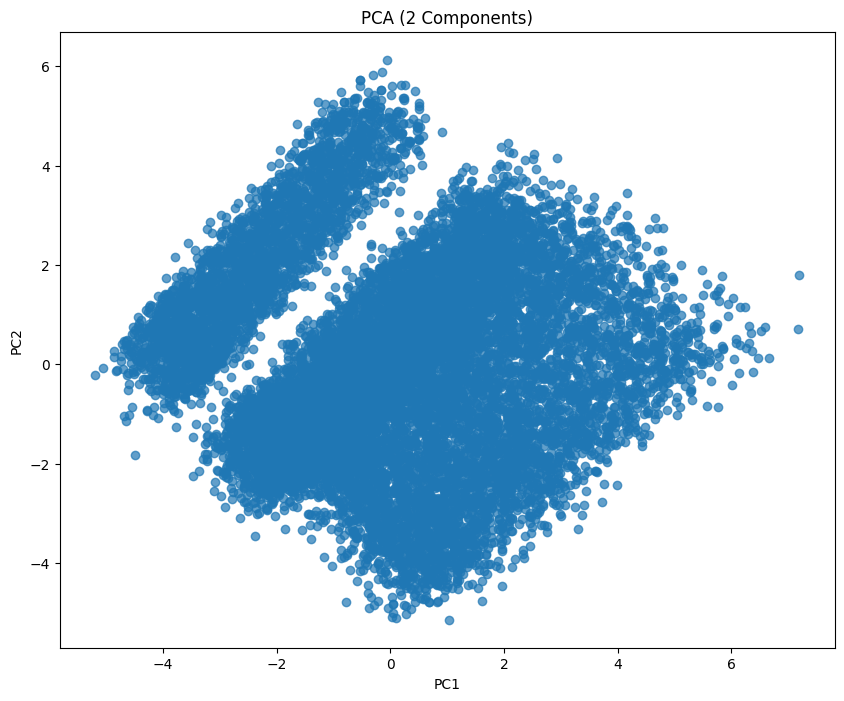

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 Components)")
plt.show()


In [ ]:
from sklearn.cluster import KMeans

# Step 1: Create model
kmeans = KMeans(n_clusters=3, random_state=42)

# Step 2: Fit on PCA data
clusters = kmeans.fit_predict(pca_df[['PC1','PC2']])

# Step 3: Add cluster labels to PCA df
pca_df['Cluster'] = clusters

# Step 4: Add cluster labels to original df (IMPORTANT)
df['Cluster'] = clusters
from sklearn.metrics import silhouette_score

# Use PCA data for silhouette evaluation
X = pca_df[['PC1', 'PC2']]

# Calculate silhouette score
sil_score = silhouette_score(X, pca_df['Cluster'])

print("Silhouette Score:", sil_score)


Silhouette Score: 0.3505340503864854


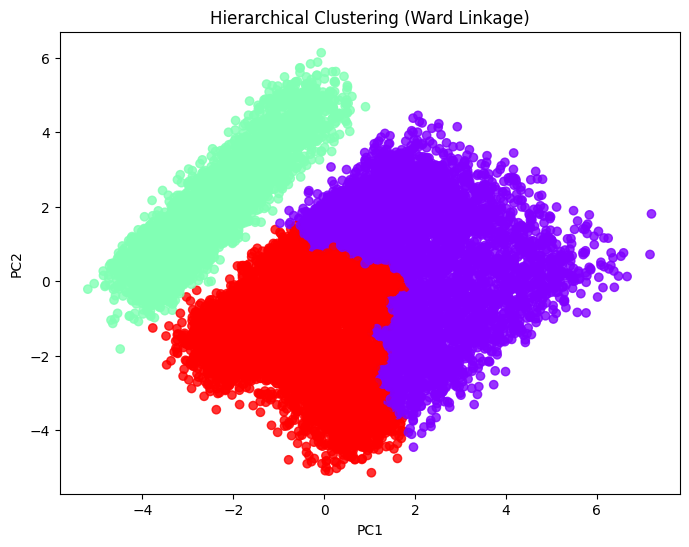

In [ ]:
# Hierarchical Clustering #

from sklearn.cluster import AgglomerativeClustering

# Use PCA data for clustering
X = pca_df[['PC1', 'PC2']]

# Create model (3 clusters)
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Fit and predict clusters
hc_labels = hc.fit_predict(X)

# Add to PCA dataframe
pca_df['HC_Cluster'] = hc_labels

# Add to original dataframe
df['HC_Cluster'] = hc_labels

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'],
            c=pca_df['HC_Cluster'], cmap='rainbow', alpha=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering (Ward Linkage)")
plt.show()



In [ ]:
###Import & Apply DBSCAN###
from sklearn.cluster import DBSCAN

# Use PCA data
X = pca_df[['PC1', 'PC2']]

# Create DBSCAN model
dbscan = DBSCAN(eps=0.3, min_samples=5)

# Fit & predict clusters
db_labels = dbscan.fit_predict(X)

# Add labels to PCA df
pca_df['DBSCAN_Cluster'] = db_labels

# Add labels to original df
df['DBSCAN_Cluster'] = db_labels


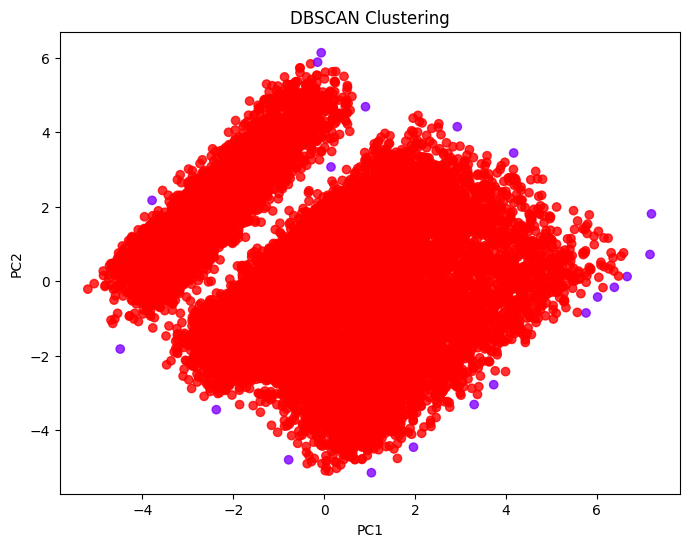

In [ ]:
###Visualize DBSCAN Clusters###
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'],
            c=pca_df['DBSCAN_Cluster'], cmap='rainbow', alpha=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering")
plt.show()


In [ ]:
#Centroids in PCA space (PC1, PC2)#
centroids_pca = kmeans.cluster_centers_
centroids_pca


array([[ 1.07800806, -2.03116675],
       [-1.88019936, -0.09804253],
       [ 1.53447134,  1.84206985]])

In [ ]:
#Centroids in original feature space (BEST for interpretation)#
from sklearn.cluster import KMeans

# Select numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
X = df[num_cols]

# Fit KMeans again on numeric data
kmeans_full = KMeans(n_clusters=3, random_state=42)
kmeans_full.fit(X)

# Get centroids
centroids = pd.DataFrame(kmeans_full.cluster_centers_, columns=num_cols)
centroids


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal),HC_Cluster,DBSCAN_Cluster
0,-0.023591,-0.019589,-0.035695,-0.022047,0.032317,0.279135,0.515181,-0.560499,0.507631,-0.443870,-0.613141,-0.653859,-0.030477,0.328816,0.253780,0.263236,-0.203600,1.930399,-0.000595
1,-0.002963,-0.009349,0.017649,0.013282,-0.009151,-1.162021,0.014605,-0.026568,0.022687,0.456975,-0.007172,-0.018269,0.012321,-1.707159,-1.510762,-1.540041,-1.078950,1.000360,-0.001802
2,0.036239,0.034242,0.041498,0.024197,-0.041685,0.292473,-0.761205,0.834600,-0.755049,0.372922,0.899795,0.965949,0.037087,0.548371,0.539626,0.543457,0.947441,0.025630,-0.002389


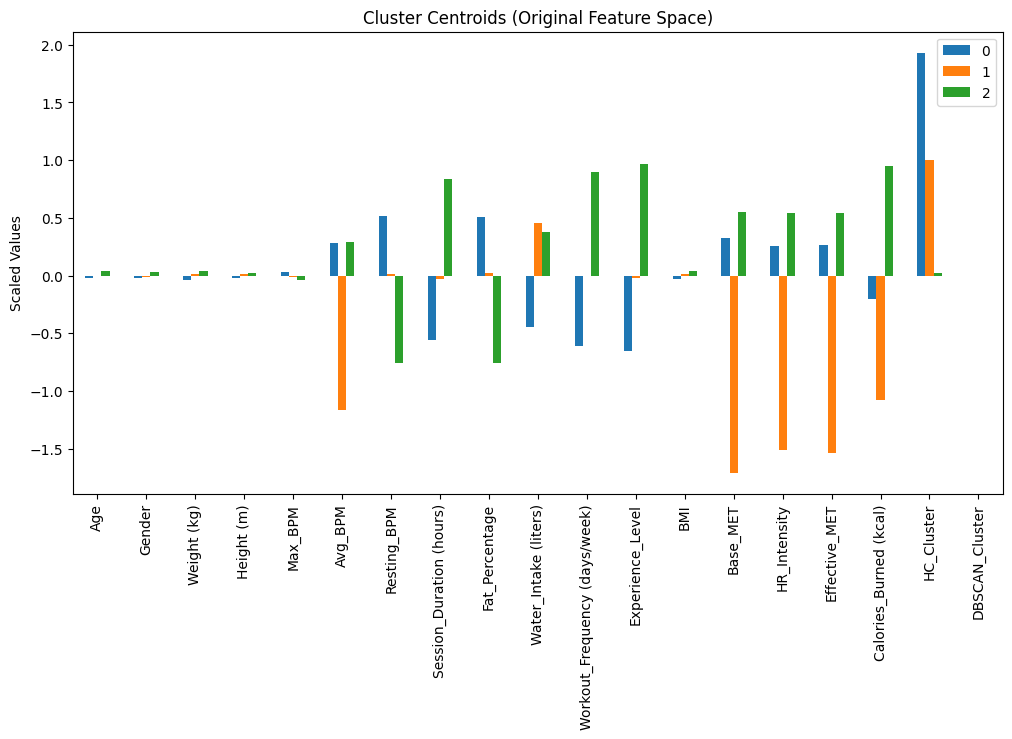

In [ ]:
#Visualize Centroids#
centroids.T.plot(kind='bar', figsize=(12,6))
plt.title("Cluster Centroids (Original Feature Space)")
plt.ylabel("Scaled Values")
plt.show()


In [ ]:
#Compute Centroids in Original Feature Space#
from sklearn.cluster import KMeans

# Select numeric columns only
num_cols = df.select_dtypes(include=['int64','float64']).columns
X = df[num_cols]

# Fit KMeans on numeric data
kmeans_full = KMeans(n_clusters=3, random_state=42)
kmeans_full.fit(X)

# Create centroid DataFrame
centroids = pd.DataFrame(kmeans_full.cluster_centers_, columns=num_cols)
centroids


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal),HC_Cluster,DBSCAN_Cluster
0,-0.023591,-0.019589,-0.035695,-0.022047,0.032317,0.279135,0.515181,-0.560499,0.507631,-0.443870,-0.613141,-0.653859,-0.030477,0.328816,0.253780,0.263236,-0.203600,1.930399,-0.000595
1,-0.002963,-0.009349,0.017649,0.013282,-0.009151,-1.162021,0.014605,-0.026568,0.022687,0.456975,-0.007172,-0.018269,0.012321,-1.707159,-1.510762,-1.540041,-1.078950,1.000360,-0.001802
2,0.036239,0.034242,0.041498,0.024197,-0.041685,0.292473,-0.761205,0.834600,-0.755049,0.372922,0.899795,0.965949,0.037087,0.548371,0.539626,0.543457,0.947441,0.025630,-0.002389


<Figure size 1400x600 with 0 Axes>

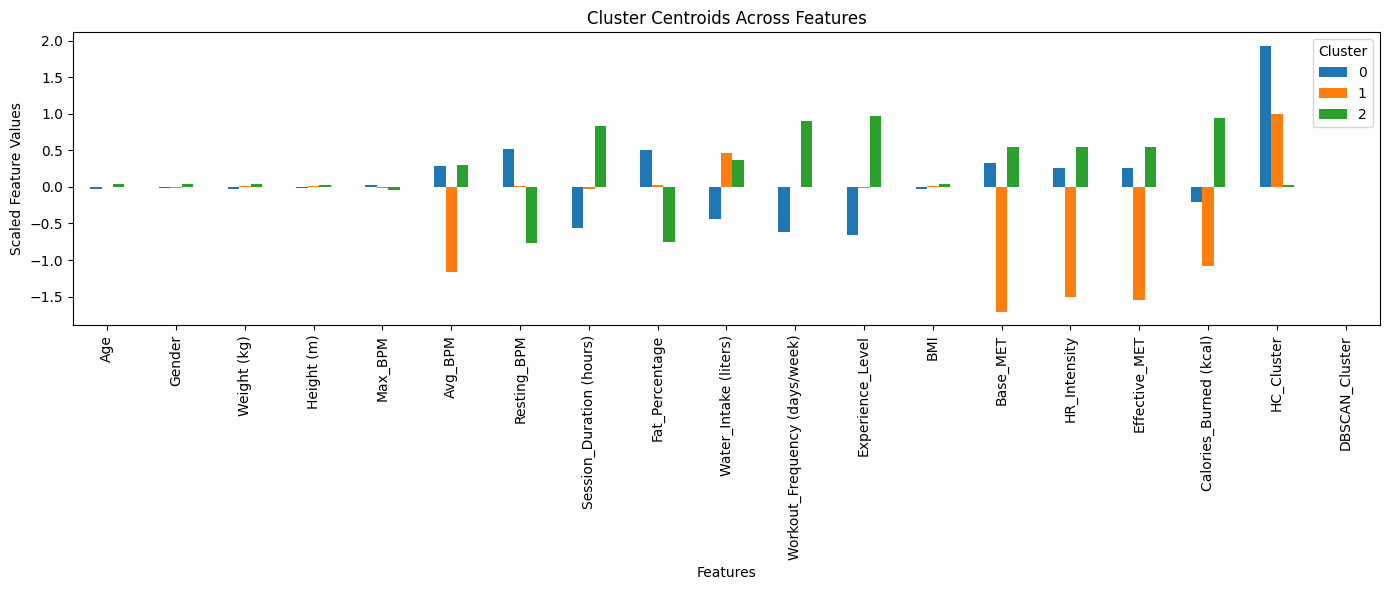

In [ ]:
#Visualize Centroids (Cluster Profile Chart)#
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
centroids.T.plot(kind='bar', figsize=(14,6))
plt.title("Cluster Centroids Across Features")
plt.ylabel("Scaled Feature Values")
plt.xlabel("Features")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import pickle

# Load data
data = pd.read_csv("/content/Fitbit_dataset.csv")
data.rename(columns={'Calories_Burned (kcal)': 'Calories'}, inplace=True)

# Remove unwanted column
data = data.drop(columns=['Unnamed: 0'], errors='ignore')

# Correct feature list
features = [
    'Age','Gender','Weight (kg)','Height (m)','Max_BPM','Avg_BPM','Resting_BPM',
    'Session_Duration (hours)','Workout_Type','Fat_Percentage',
    'Water_Intake (liters)','Workout_Frequency (days/week)',
    'Experience_Level','BMI','Base_MET','HR_Intensity','Effective_MET'
]

X = data[features]
y = data['Calories']

# -----------------------------
# ENCODE CATEGORICAL COLUMNS
# -----------------------------
cat_cols = ['Gender', 'Workout_Type', 'Experience_Level']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# -----------------------------
# SCALE NUMERIC FEATURES
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# TRAIN MODEL
# -----------------------------
model = RandomForestRegressor(
    n_estimators=40,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=0.3,
    random_state=42
)
model.fit(X_scaled, y)

# -----------------------------
# SAVE FILES
# -----------------------------
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(features, open("feature_list.pkl", "wb"))
pickle.dump(encoders, open("encoders.pkl", "wb"))



NameError: name 'user_input' is not defined

In [ ]:
from google.colab import files
files.download("model.pkl")
files.download("scaler.pkl")
files.download("feature_list.pkl")
files.download("encoders.pkl")